In [6]:
%load_ext autoreload
%autoreload 2

import argparse
import os
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt

import utils.behavioral_utils as behavioral_utils
import utils.io_utils as io_utils
import utils.spike_utils as spike_utils
import utils.visualization_utils as visualization_utils

from constants.behavioral_constants import *
from constants.decoding_constants import *
from scripts.anova_analysis.stim_belief_unit_overlap import OUTPUT_PATH, ALPHA
from scripts.pseudo_decoding.belief_partitions.stim_belief_vector_alignment import (
    prep_behavior_for_feat, group_masks, BASE_GROUPS,
)

plt.rcParams.update({"font.size": 16})

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Co-selective example units

`20260820_visualize_stim_belief_unit_overlap.ipynb` reports whether stimulus- and belief-selective
units overlap more than chance. This notebook looks at the individual units inside `N11` -- the
ones selective in *both* runs -- and plots what their firing rates actually do across the three
groups the two contrasts are built from:

```
A: X not chosen, X not preferred     B: X chosen, X not preferred     C: X chosen, X preferred
        \________ Run S ________/            \________ Run P ________/
         the stimulus contrast                  the belief contrast
```

A unit in `N11` is one whose firing rate separates A from B *and* separates B from C, at the same
feature and the same window. Under H1 those should be different units; the ones here are the
counterexamples, and the point of the plot is to see whether they look like real dual coding or
like the tail of a noise distribution.

**"Both selective" means both permutation p-values at their floor**, not a large eta^2. Raw eta^2
is not comparable across units -- a unit's null level depends on its firing statistics -- which is
why the analysis calibrates per item in the first place. So candidates are ranked on the calibrated
p-values, and eta^2 is used only to break ties among items that share the same floored p.

Two caveats on reading these PSTHs:

- These are the **most extreme** items out of ~5,900 per window, selected *because* they are
  extreme. Some will be real dual-coding neurons and some will be the upper tail of the null --
  at alpha = 0.05 in both runs, chance alone puts ~0.25% of items in `N11`. A single convincing
  PSTH is not evidence for H3; the population statistic in the other notebook is.
- The analysis split group B into disjoint halves (B1 for Run S, B2 for Run P) so the two runs
  share no trials. The PSTH pools all of B, because halving it would double the noise on the
  middle trace for no gain -- this is a picture, not a test.
- Examples are drawn only from the **6 regions of interest** the decoding analyses use (AMY, DSTR,
  ITC, HC, LPFC, ACC). The overlap statistics themselves are computed over a wider `whole_pop`, so
  the counts here are a subset of the `N11` those plots report.


In [7]:
TRIAL_EVENT = "FeedbackOnsetLong"
N_EXAMPLES = 20

# A -> B is the stimulus step and B -> C the belief step, so B and C take the colours the repo
# already uses for those two variables and A is the neutral starting point
GROUP_TO_COLOR = {
    "A": "grey",
    "B": visualization_utils.MODE_TO_COLOR["feature"],
    "C": visualization_utils.MODE_TO_COLOR["preference"],
}
GROUP_TO_LABEL = {
    "A": "A: not selected, not pref.",
    "B": "B: selected, not pref.",
    "C": "C: selected, pref.",
}

WINDOW_SIZE = 500

# what counts as "not selective" for whichever run is playing the null role in the two
# dissociation sections. Deliberately not just p > alpha, which would admit p = 0.06 -- a unit that
# nearly cleared the bar is a weak illustration of a unit that does not encode the variable. At 0.5
# the unit's true eta^2 sits below the MEDIAN of its own shuffles, i.e. no hint of an effect at all
NULL_MIN = 0.5


def read_items(trial_event=TRIAL_EVENT, regions=REGIONS_OF_INTEREST):
    """
    The true run's per-item table: one row per (unit, feature, window), both runs' p-values and
    eta^2, written by stim_belief_unit_overlap.py so exactly this kind of lookup is a filter
    rather than a re-read of the 9 GB grid.

    Restricted to the 6 regions the decoding analyses use, so an example unit is always one that
    the rest of the paper has something to say about. Note this is NARROWER than the population the
    statistics in 20260820_visualize_stim_belief_unit_overlap.ipynb are computed over: `whole_pop`
    there is every unit surviving the good-units merge, which includes regions outside these 6
    (V1, LVPal and so on). Pass regions=None to draw examples from that wider set instead.
    """
    items = pd.read_pickle(os.path.join(OUTPUT_PATH, f"{trial_event}_item_pvals.pickle"))
    items = items[items.in_good_units].copy()
    if regions is None:
        return items
    in_roi = items.structure_level2_cleaned.isin(regions)
    print(f"{in_roi.sum()} of {len(items)} items are in the {len(regions)} regions of interest "
          f"({items[in_roi].PseudoUnitID.nunique()} of {items.PseudoUnitID.nunique()} units)")
    return items[in_roi].copy()


def find_candidates(items, alpha=ALPHA):
    """
    Items selective in BOTH runs, strongest first.

    Ranked on `p_worse` = max(p_s, p_p): an item is only as co-selective as its weaker side, so
    that is what has to be small. With 100 shuffles the p-value grid has a floor at 0.01 and many
    items tie there, so eta^2 breaks ties -- purely to pick visually clear examples, NOT as a
    statistic. eta^2 is not comparable across units, which is the whole reason the p-values exist.
    """
    both = items[(items.p_s <= alpha) & (items.p_p <= alpha)].copy()
    both["p_worse"] = both[["p_s", "p_p"]].max(axis=1)
    both["eta2_prod"] = both.eta2_s * both.eta2_p
    return both.sort_values(["p_worse", "eta2_prod"], ascending=[True, False])


def pick_examples(candidates, n=N_EXAMPLES):
    """
    One row per unit -- its best (feature, window) -- so n examples are n different neurons.

    Without this the top of the list is often one unit appearing at several adjacent windows, which
    overlap by 80% and are therefore the same observation shown repeatedly.
    """
    return candidates.drop_duplicates(subset="PseudoUnitID").head(n)

def region_abbrev(region):
    """
    Short region label. REGION_TO_ABBREV only covers the 6 regions of interest, and these examples
    can land anywhere, so anything else falls back to the code the region string already ends in
    ("lateral_and_ventral_pallium_LVPal" -> "LVPal") rather than overflowing the title.
    """
    return visualization_utils.REGION_TO_ABBREV.get(region, str(region).split("_")[-1])

# the two one-sided sections, as (selective run, null run, tiebreak). Written once so the belief
# and stimulus sections are symmetric by construction rather than by two edits staying in sync
DISSOCIATIONS = {
    "belief": ("p_p", "p_s", "eta2_p"),
    "stim":   ("p_s", "p_p", "eta2_s"),
}


def find_dissociated(items, selective, alpha=ALPHA, null_min=NULL_MIN):
    """
    Items selective in ONE run and conspicuously not the other -- what H1 says both codes should
    look like, and the complement of find_candidates.

    `selective` is "belief" (p_b low, p_s high) or "stim" (p_s low, p_b high).

    Ranked on the calibrated scale in both directions: the selective run's p ascending (strongest
    evidence) then the null run's p descending (least evidence for the other variable), so the top
    of the list is the cleanest available dissociation. eta^2 only breaks what is still tied after
    that, and as in find_candidates it is a display heuristic rather than a statistic -- eta^2 does
    not compare across units.
    """
    sel_col, null_col, eta_col = DISSOCIATIONS[selective]
    hits = items[(items[sel_col] <= alpha) & (items[null_col] >= null_min)].copy()
    return hits.sort_values([sel_col, null_col, eta_col], ascending=[True, False, False])

## Co-selective units: selective in BOTH runs

The `N11` set -- units whose firing separates A from B *and* B from C, at the same feature and
window. These are the counterexamples to H1.

`N11` per window is in the tens, so the pool across all windows is a few hundred out of ~170k items.

In [8]:
items = read_items()
candidates = find_candidates(items)
examples = pick_examples(candidates)

print(f"{len(items)} items, {len(candidates)} selective in both runs at alpha={ALPHA} "
      f"({100 * len(candidates) / len(items):.2f}%), "
      f"across {candidates.PseudoUnitID.nunique()} distinct units")
print(f"\nchance expectation if the two runs were independent: "
      f"~{ALPHA**2 * 100:.2f}% of items\n")

print("units contributing, by region:")
print(candidates.groupby("structure_level2_cleaned").PseudoUnitID.nunique()
      .rename(region_abbrev).sort_values(ascending=False).to_string(), "\n")

cols = ["PseudoUnitID", "feat", "WindowStartMilli", "subject",
        "structure_level2_cleaned", "p_s", "p_p", "eta2_s", "eta2_p"]
display(examples[cols].reset_index(drop=True))

109445 of 170726 items are in the 6 regions of interest (869 of 1378 units)
109445 items, 555 selective in both runs at alpha=0.05 (0.51%), across 186 distinct units

chance expectation if the two runs were independent: ~0.25% of items

units contributing, by region:
structure_level2_cleaned
LPFC    61
ITC     45
AMY     21
ACC     21
HC      20
DSTR    18 



,PseudoUnitID,feat,WindowStartMilli,subject,structure_level2_cleaned,p_s,p_p,eta2_s,eta2_p
0,2018090724,ESCHER,-900,SA,amygdala_Amy,0.01,0.01,0.302624,0.074260
1,2018092819,ESCHER,-600,SA,inferior_temporal_cortex_ITC,0.01,0.01,0.111741,0.116547
2,2018092500,GREEN,-500,SA,inferior_temporal_cortex_ITC,0.01,0.01,0.165795,0.077061
3,20180725000115,YELLOW,400,SA,lateral_prefrontal_cortex_lat_PFC,0.01,0.01,0.048395,0.086604
4,2018092001,RIPPLE,-300,SA,basal_ganglia_BG,0.01,0.01,0.029198,0.128943
5,2018090525,RIPPLE,-400,SA,amygdala_Amy,0.01,0.01,0.063957,0.043032
6,2018090600,CYAN,-300,SA,inferior_temporal_cortex_ITC,0.01,0.01,0.027853,0.074632
7,2018070924,SQUARE,-200,SA,inferior_temporal_cortex_ITC,0.01,0.01,0.032028,0.063159
8,2018092620,SQUARE,-600,SA,inferior_temporal_cortex_ITC,0.01,0.01,0.028386,0.055839
9,2018080614,GREEN,700,SA,lateral_prefrontal_cortex_lat_PFC,0.01,0.01,0.018014,0.086644


### PSTHs

Raw firing rate against time to feedback, averaged over each group's trials with a standard error
band. The shaded span is the 500 ms window the unit was flagged in. One figure per unit,
each with its own x axis, so a single panel can be copied out on its own.

Read **A vs B for the stimulus effect** and **B vs C for the belief effect**. A genuinely
co-selective unit should separate on *both* steps; one that landed in `N11` by chance usually shows
one clear step and a middle trace that wanders.

In [9]:
def load_unit_psth(unit_id, feat, trial_event=TRIAL_EVENT):
    """
    One unit's trial-by-trial firing rates, labelled with its A/B/C group.

    The session is recoverable from the PseudoUnitID, which is int(session) * 100 + UnitID, so a
    row of the item table is enough to find the data. Groups come from
    stim_belief_vector_alignment rather than being redefined here -- that module is what the
    population analysis and the ANOVA runs both use, so the three cells are identical by
    construction rather than by hand.
    """
    session = str(unit_id // 100)
    subject = behavioral_utils.get_sub_for_session(session)

    args = argparse.Namespace(
        subject=subject, trial_event=trial_event, fr_type="firing_rates",
        trial_interval=get_trial_interval(trial_event), time_range=None,
    )
    beh = prep_behavior_for_feat(
        behavioral_utils.get_valid_belief_beh_for_sub_sess(subject, session), feat
    )
    masks = group_masks(beh)
    beh["group"] = np.select([masks[g] for g in BASE_GROUPS], BASE_GROUPS, default=None)
    beh = beh[beh.group.notna()]

    frs = io_utils.get_frs_from_args(args, session)
    frs = frs[frs.PseudoUnitID == unit_id]
    return pd.merge(frs, beh[["TrialNumber", "group"]], on="TrialNumber"), subject

# shared by every panel now that each is its own figure
FB_TICKS = [-1.5, -1, -.5, 0, .5, 1, 1.5]


def plot_psth(row, ax):
    """One example unit, on a supplied axes."""
    psth, subject = load_unit_psth(row.PseudoUnitID, row.feat)
    n_per_group = psth.groupby("group").TrialNumber.nunique()

    sns.lineplot(
        psth, x="Time", y="FiringRate", hue="group", hue_order=BASE_GROUPS,
        palette=GROUP_TO_COLOR, linewidth=3, errorbar="se", ax=ax
    )
    # the window the unit was flagged in, so the traces can be read where the test looked
    ax.axvspan(row.WindowStartMilli / 1000, (row.WindowStartMilli + WINDOW_SIZE) / 1000,
               color="grey", alpha=0.12, linewidth=0)
    ax.axvline(-.8, color="grey", linestyle="dotted", linewidth=3)
    ax.axvline(0, color="grey", linestyle="dotted", linewidth=3)

    ax.set_ylabel("firing rate (Hz)")
    # every panel carries its own x axis: the figures are drawn one per unit so that a single PSTH
    # can be copied out on its own, and a copied panel with no x axis is unreadable
    ax.set_xlabel("Time to feedback (s)")
    ax.set_xticks(FB_TICKS)
    ax.set_xticklabels(FB_TICKS)
    # identity only -- which unit, which animal and region, which feature X the groups are relative
    # to, and the trial counts behind each trace. The numbers that selected the unit are in the
    # table printed above each set, not on the figure
    ax.set_title(
        f"unit {int(row.PseudoUnitID)}  ({subject}, {region_abbrev(row.structure_level2_cleaned)})"
        f"  |  X = {row.feat}\n"
        f"n = {', '.join(f'{g}:{n_per_group.get(g, 0)}' for g in BASE_GROUPS)}",
        fontsize=11,
    )
    ax.get_legend().remove()
    return ax


def plot_examples(examples):
    """
    One standalone figure per example unit rather than a single stacked column, so an individual
    PSTH can be copied out without cropping the ones above and below it. Returns the figures and
    their axes, in the order the examples came in.
    """
    figs, axs = [], []
    for _, row in examples.iterrows():
        fig, ax = plt.subplots(figsize=(8.5, 3.0))
        plot_psth(row, ax)
        # legend beside each panel, the repo's usual placement. With one panel per figure there is
        # no stack to share a legend across, and this keeps every figure self-contained
        handles = [plt.Line2D([], [], color=GROUP_TO_COLOR[g], linewidth=6, label=GROUP_TO_LABEL[g])
                   for g in BASE_GROUPS]
        ax.legend(handles=handles, loc="center left", bbox_to_anchor=(1.02, 0.5), frameon=False,
                  fontsize=11)
        visualization_utils.format_plot([ax])
        fig.tight_layout()
        figs.append(fig)
        axs.append(ax)
    return figs, axs


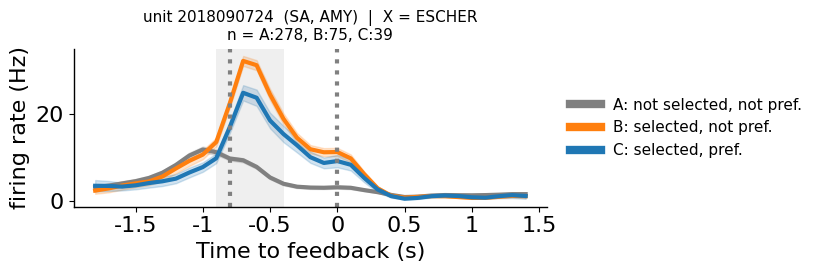

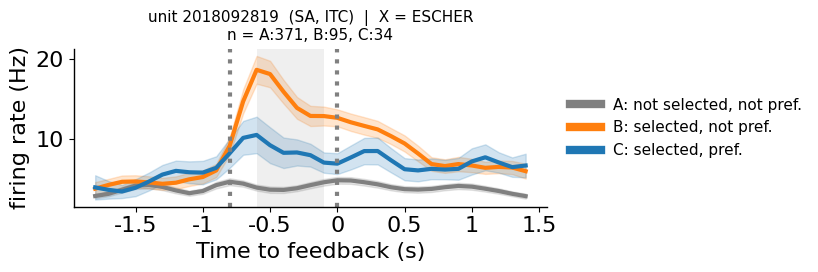

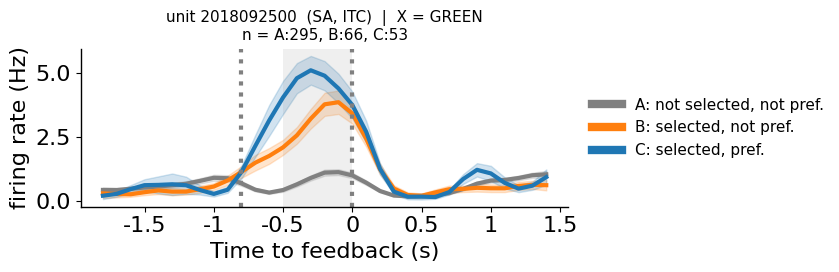

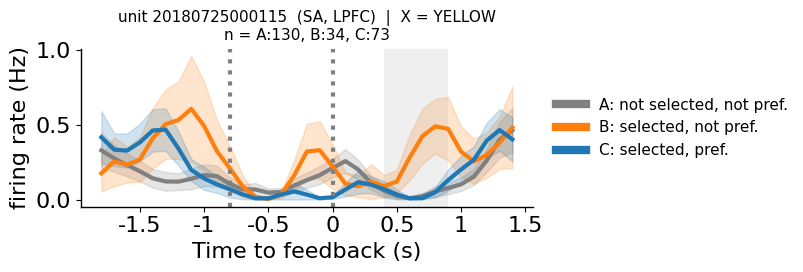

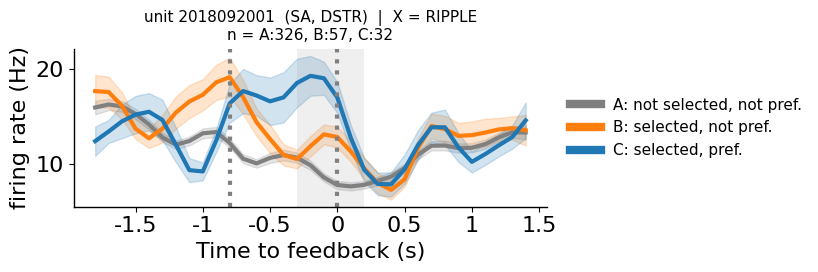

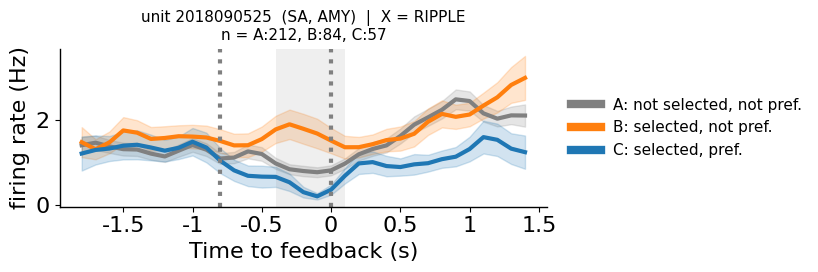

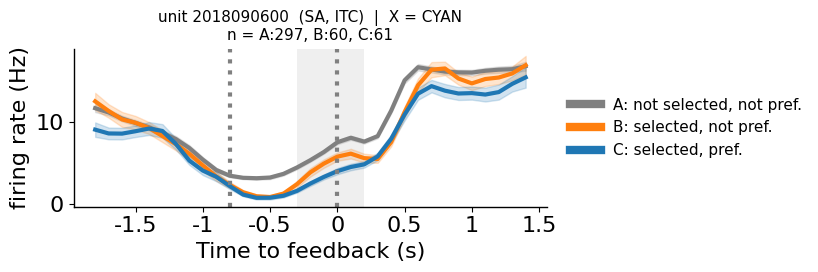

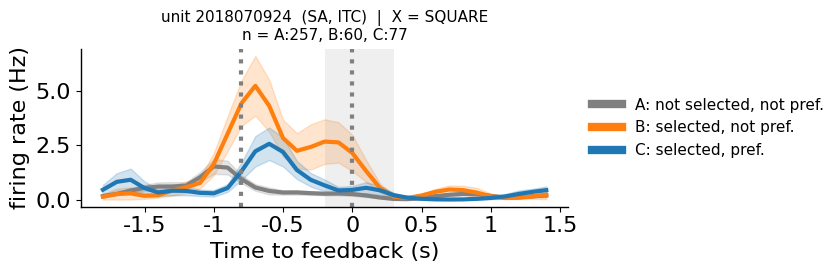

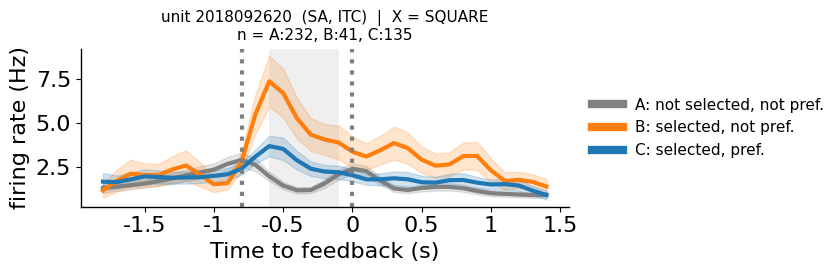

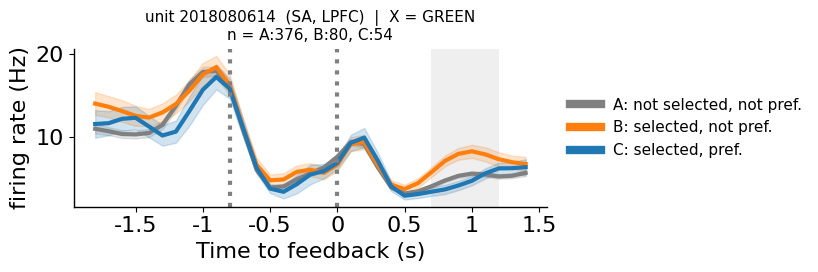

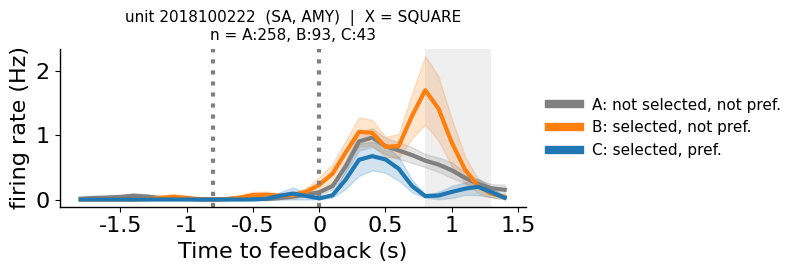

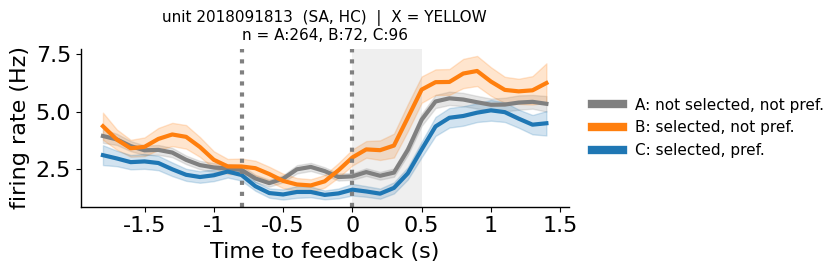

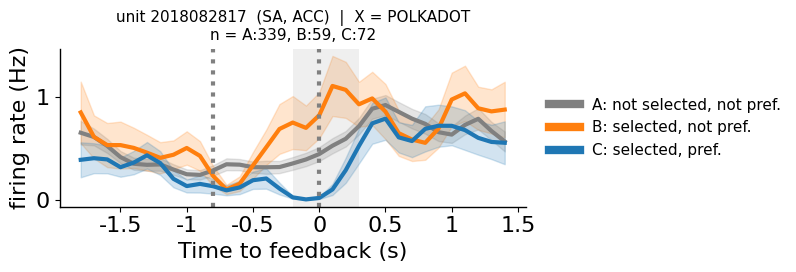

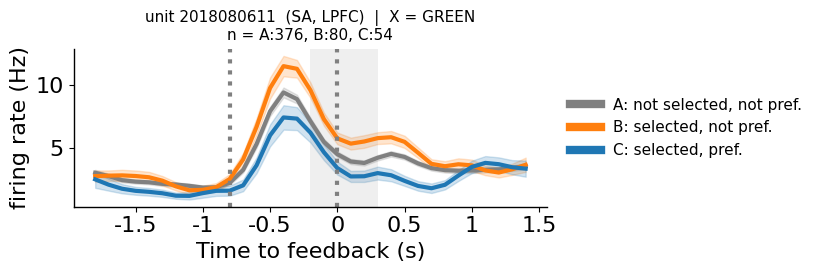

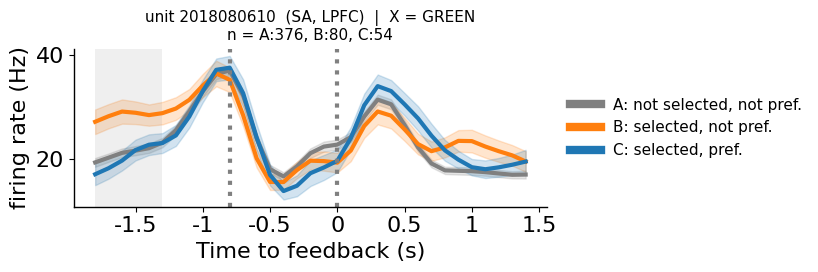

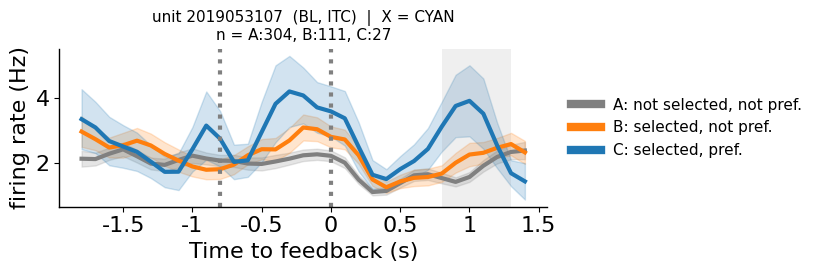

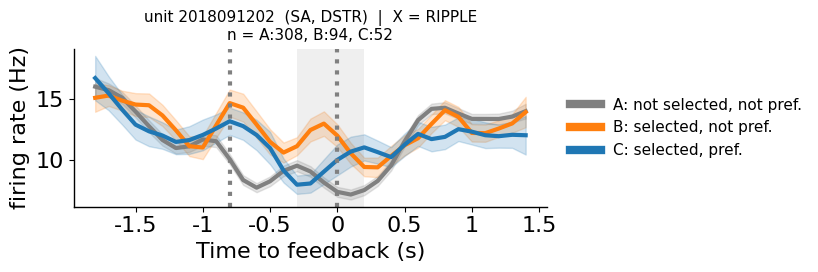

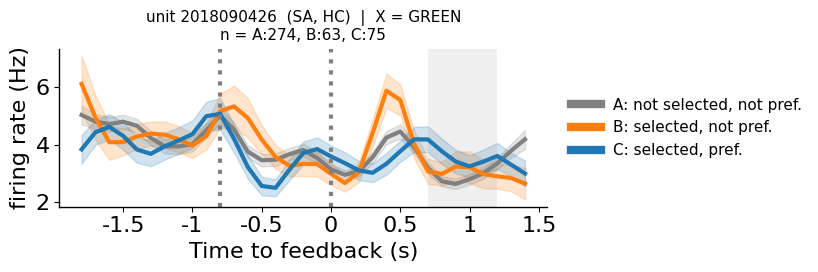

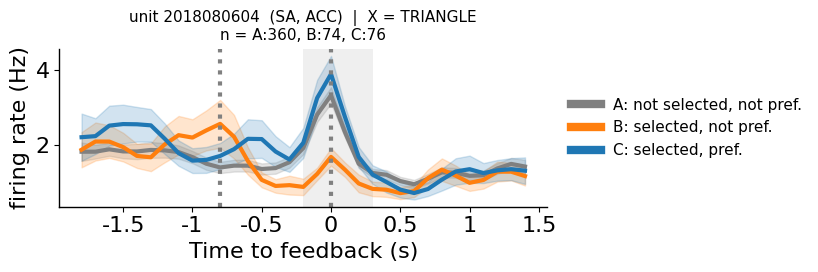

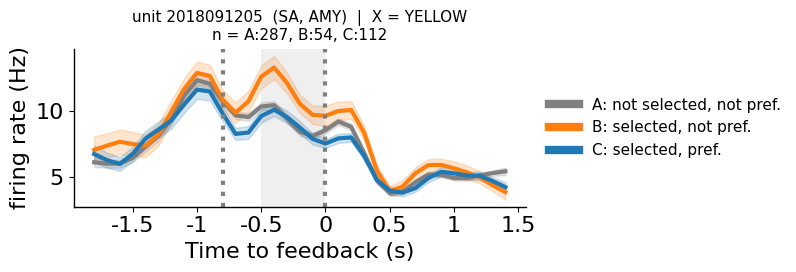

In [10]:
figs, axs = plot_examples(examples)

---

## Belief-only units: selective in Run P but not Run S

The complement, and what H1 predicts the belief code is made of: units that separate B from C while
showing no trace of an A-vs-B stimulus effect.

Selection is two-sided on the calibrated scale -- `p_p <= alpha` for the belief effect, and
`p_s >= 0.5` for the absence of a stimulus one. That second bar is deliberately far above `alpha`:
a unit at `p_s = 0.06` did not *quite* reach significance, which is a poor illustration of a unit
that does not encode stimulus at all. At 0.5 the unit's true stimulus eta^2 sits below the median
of its own shuffles.

These should be far more numerous than the co-selective set, for two reasons that are worth keeping
apart: H1 predicts the codes are carried by different neurons, but also Run P simply detects less
than Run S does, so the marginals differ. The count printed below is not itself evidence either way
-- that is what the overlap ratio normalises out.

In [11]:
belief_only = find_dissociated(items, "belief")
belief_examples = pick_examples(belief_only)

print(f"{len(belief_only)} items selective in Run P (p_b <= {ALPHA}) with no stimulus effect "
      f"(p_s >= {NULL_MIN}), across {belief_only.PseudoUnitID.nunique()} distinct units")
print(f"for comparison: {len(candidates)} co-selective items across "
      f"{candidates.PseudoUnitID.nunique()} units\n")

print("units contributing, by region:")
print(belief_only.groupby("structure_level2_cleaned").PseudoUnitID.nunique()
      .rename(region_abbrev).sort_values(ascending=False).to_string(), "\n")

display(belief_examples[cols].reset_index(drop=True))

2951 items selective in Run P (p_b <= 0.05) with no stimulus effect (p_s >= 0.5), across 586 distinct units
for comparison: 555 co-selective items across 186 units

units contributing, by region:
structure_level2_cleaned
LPFC    174
ITC     147
HC       83
DSTR     67
ACC      64
AMY      51 



,PseudoUnitID,feat,WindowStartMilli,subject,structure_level2_cleaned,p_s,p_p,eta2_s,eta2_p
0,2018061504,CIRCLE,-1000,SA,lateral_prefrontal_cortex_lat_PFC,1.00,0.01,0.000165,0.159912
1,2018090635,SQUARE,400,SA,amygdala_Amy,1.00,0.01,0.000093,0.073950
2,2018091808,YELLOW,800,SA,lateral_prefrontal_cortex_lat_PFC,1.00,0.01,0.000108,0.067234
3,2018092404,CYAN,-1600,SA,inferior_temporal_cortex_ITC,1.00,0.01,0.000113,0.066962
4,2018100801,STAR,400,SA,inferior_temporal_cortex_ITC,1.00,0.01,0.000189,0.065629
5,2018061502,SQUARE,-400,SA,inferior_temporal_cortex_ITC,1.00,0.01,0.000210,0.058661
6,2018092816,YELLOW,900,SA,inferior_temporal_cortex_ITC,1.00,0.01,0.000224,0.054245
7,2019090409,POLKADOT,-900,BL,medial_pallium_MPal,1.00,0.01,0.000213,0.046942
8,2018080214,TRIANGLE,600,SA,anterior_cingulate_gyrus_ACgG,1.00,0.01,0.000076,0.043415
9,2018081308,YELLOW,1000,SA,anterior_cingulate_gyrus_ACgG,0.99,0.01,0.000060,0.174234


### PSTHs

Same axes as above. Here the pattern to look for is the *opposite* one: **B and C apart, A and B
together** -- belief separating the two chosen conditions while selection does nothing.

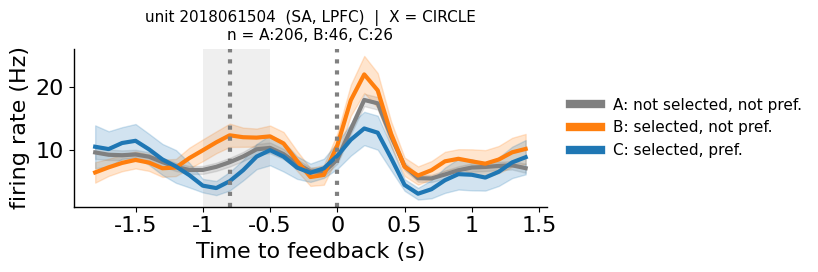

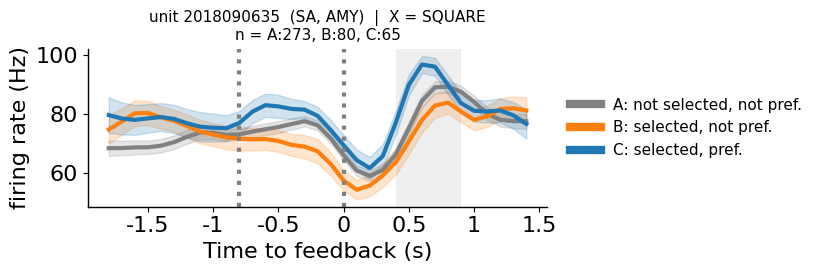

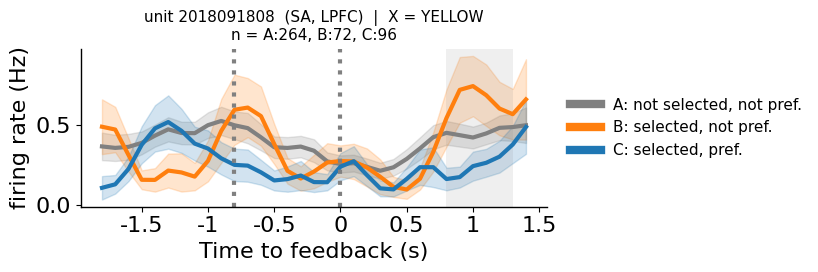

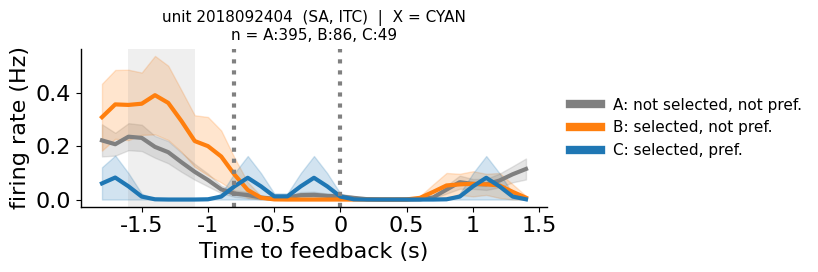

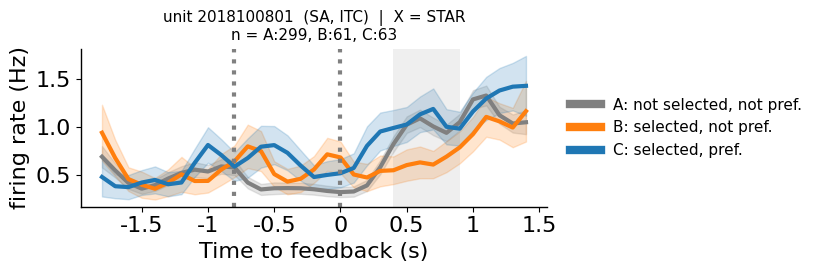

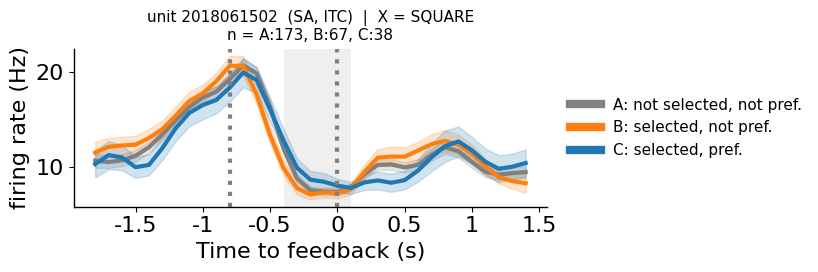

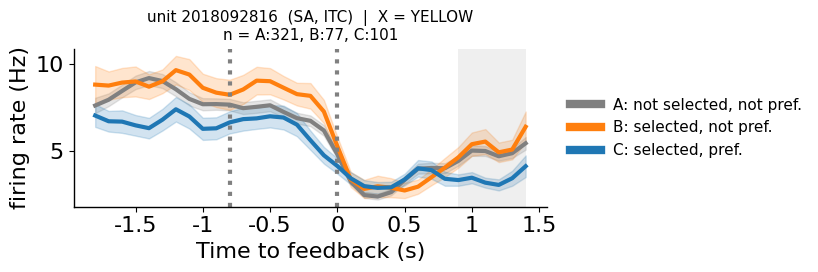

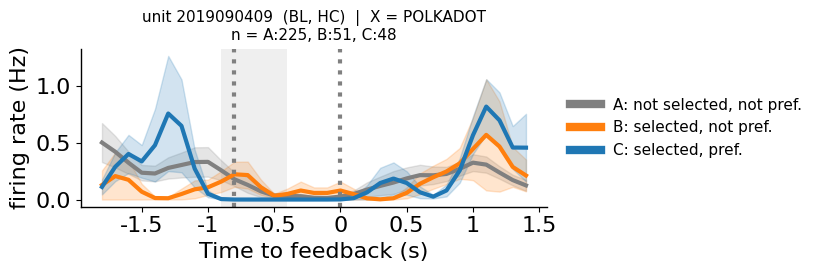

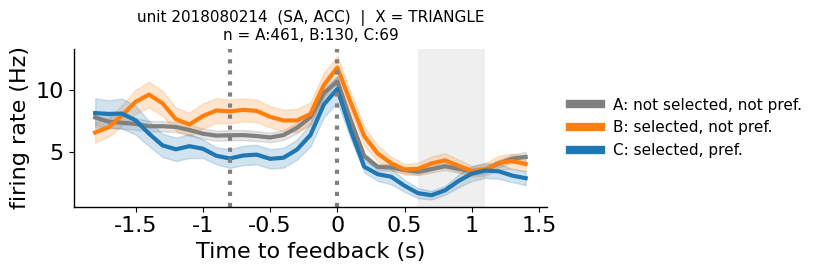

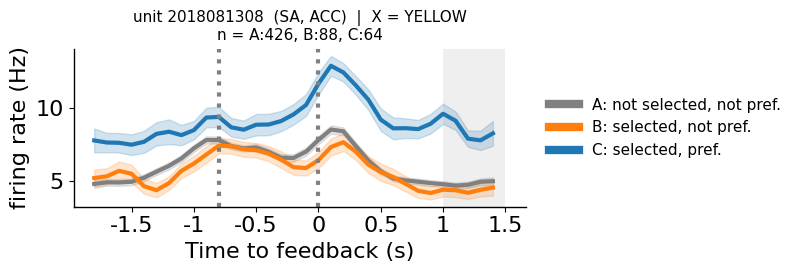

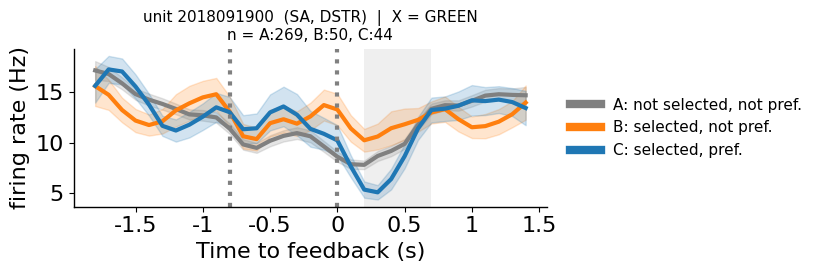

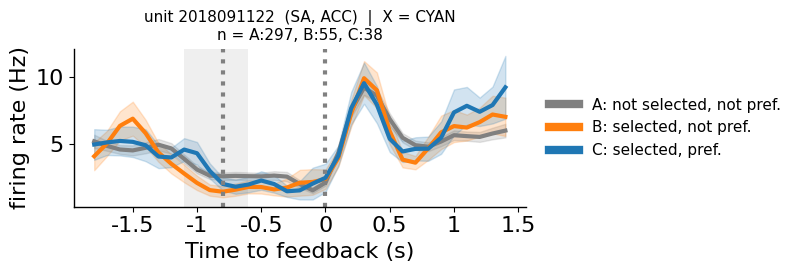

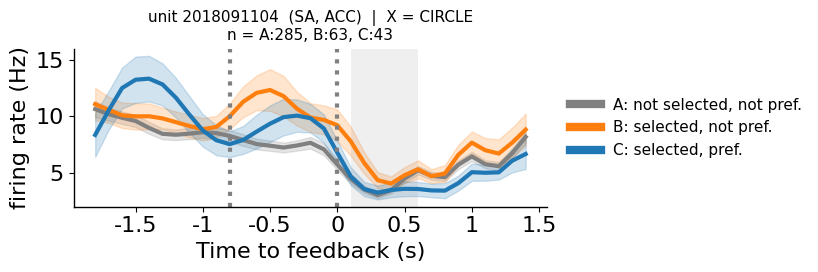

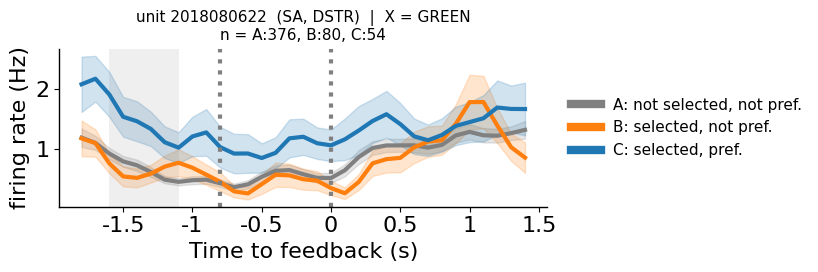

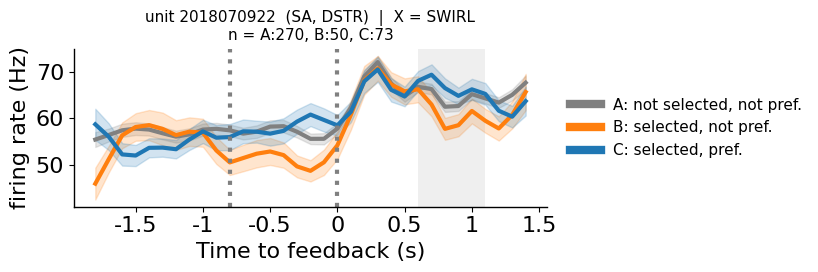

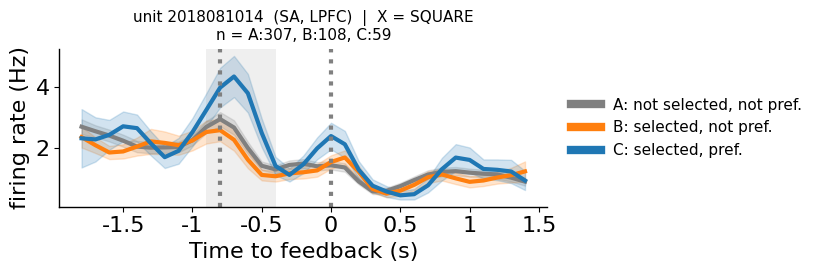

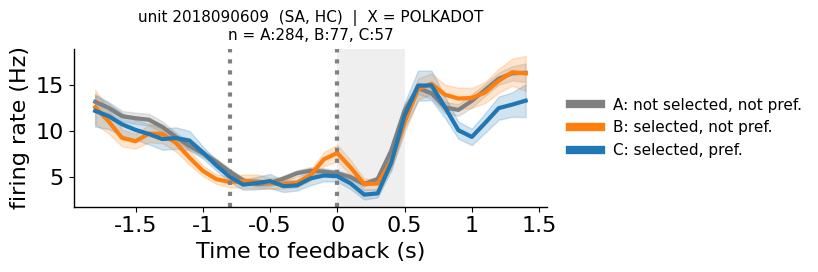

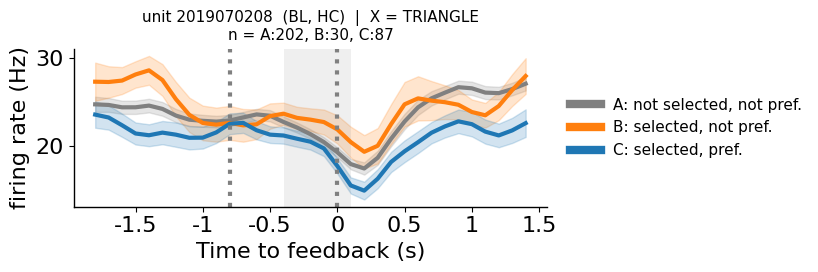

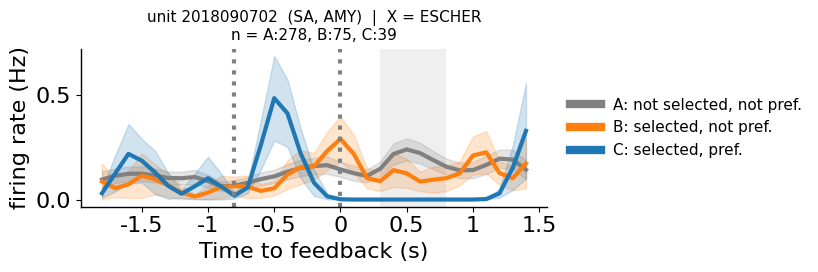

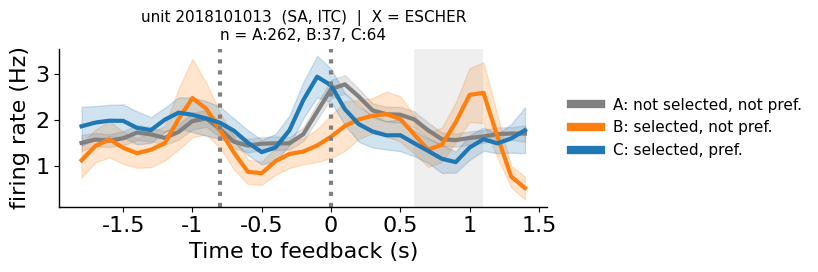

In [12]:
figs, axs = plot_examples(belief_examples)

---

## Stimulus-only units: selective in Run S but not Run P

The mirror of the previous section, and the other half of what H1 predicts: units that separate
A from B while showing no trace of a B-vs-C belief effect. Same two-sided rule, sides swapped --
`p_s <= alpha` for the stimulus effect, `p_b >= 0.5` for the absence of a belief one.

**Expect this to be much the largest of the three sets, and do not read that as evidence for H1.**
It mostly restates the two runs' very different power. Run S detects real selectivity in roughly
6% of items above the alpha floor; Run P manages about 1%. So most items have a high `p_b` simply
because the belief contrast finds little in anything, not because these particular units are
established non-coders of belief. Turning that asymmetry into a statement about overlap is exactly
what the marginal normalisation in `rho` does, and it is the plot in the other notebook -- not
these counts -- that carries the inference.

In [13]:
stim_only = find_dissociated(items, "stim")
stim_examples = pick_examples(stim_only)

print(f"{len(stim_only)} items selective in Run S (p_s <= {ALPHA}) with no belief effect "
      f"(p_b >= {NULL_MIN}), across {stim_only.PseudoUnitID.nunique()} distinct units")
print(f"for comparison: {len(belief_only)} belief-only, {len(candidates)} co-selective\n")

print("units contributing, by region:")
print(stim_only.groupby("structure_level2_cleaned").PseudoUnitID.nunique()
      .rename(region_abbrev).sort_values(ascending=False).to_string(), "\n")

display(stim_examples[cols].reset_index(drop=True))

4084 items selective in Run S (p_s <= 0.05) with no belief effect (p_b >= 0.5), across 619 distinct units
for comparison: 2951 belief-only, 555 co-selective

units contributing, by region:
structure_level2_cleaned
LPFC    174
ITC     165
HC       84
DSTR     75
AMY      64
ACC      57 



,PseudoUnitID,feat,WindowStartMilli,subject,structure_level2_cleaned,p_s,p_p,eta2_s,eta2_p
0,2018092005,ESCHER,-700,SA,inferior_temporal_cortex_ITC,0.01,1.00,0.167673,0.000290
1,2018061537,SQUARE,-100,SA,basal_ganglia_BG,0.01,1.00,0.030731,0.000515
2,2018080123,SQUARE,-500,SA,lateral_prefrontal_cortex_lat_PFC,0.01,1.00,0.029838,0.000416
3,2018070936,POLKADOT,-100,SA,basal_ganglia_BG,0.01,1.00,0.024034,0.000189
4,2018091920,SQUARE,-900,SA,basal_ganglia_BG,0.01,1.00,0.023651,0.000754
5,2018080611,TRIANGLE,-500,SA,lateral_prefrontal_cortex_lat_PFC,0.01,1.00,0.020759,0.000553
6,2018100504,RIPPLE,-900,SA,lateral_prefrontal_cortex_lat_PFC,0.01,1.00,0.020197,0.000227
7,2018090417,GREEN,700,SA,medial_pallium_MPal,0.01,1.00,0.019909,0.000467
8,2018092512,YELLOW,-300,SA,basal_ganglia_BG,0.01,1.00,0.017957,0.001246
9,2018081007,CIRCLE,-400,SA,anterior_cingulate_gyrus_ACgG,0.01,1.00,0.016164,0.000138


### PSTHs

Same axes again. The pattern here is **A and B apart, B and C together** -- selection separating
the chosen from the unchosen while preference does nothing on top of it.

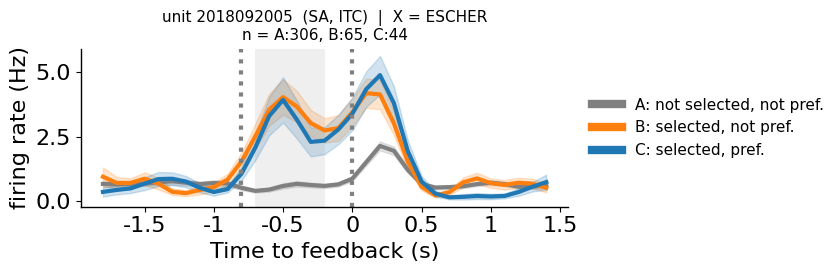

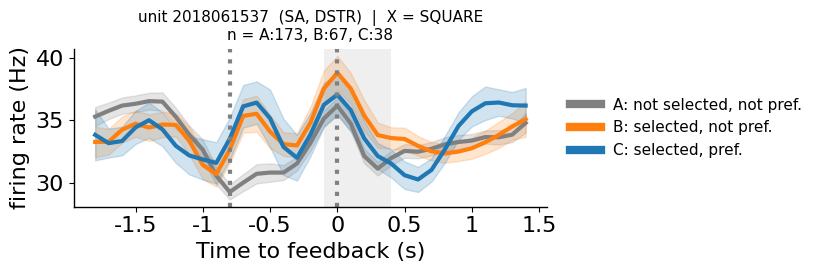

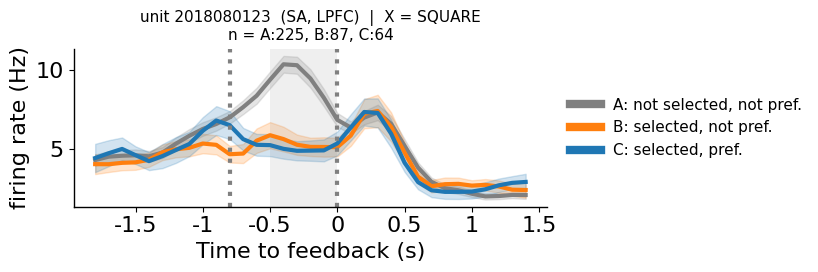

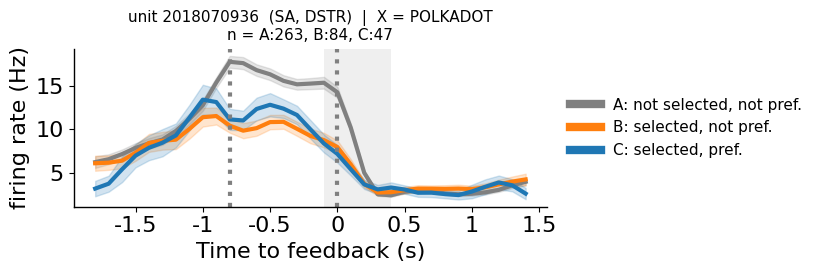

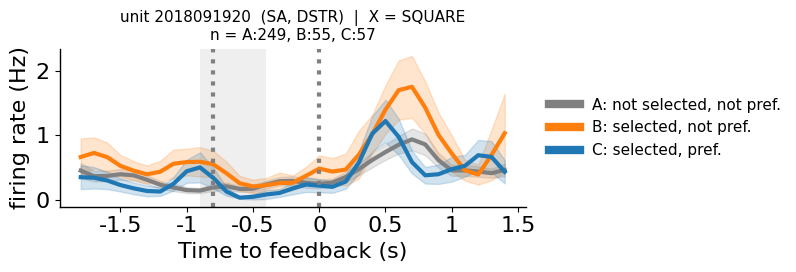

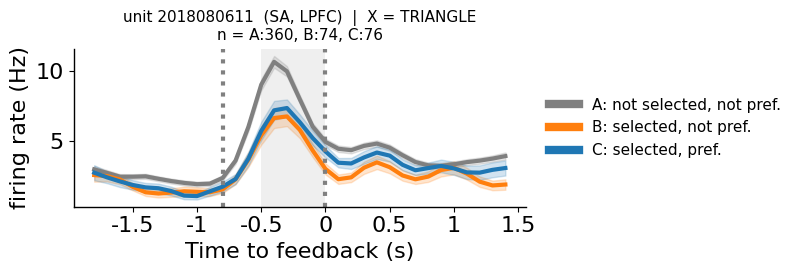

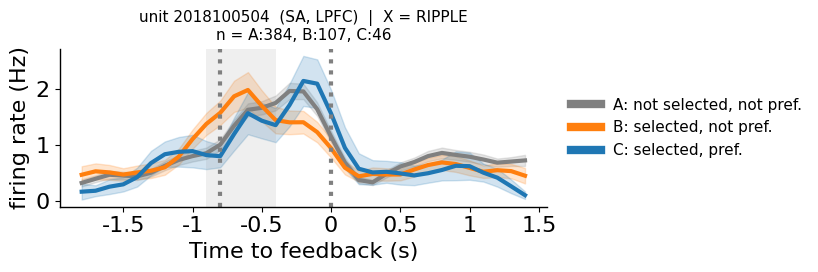

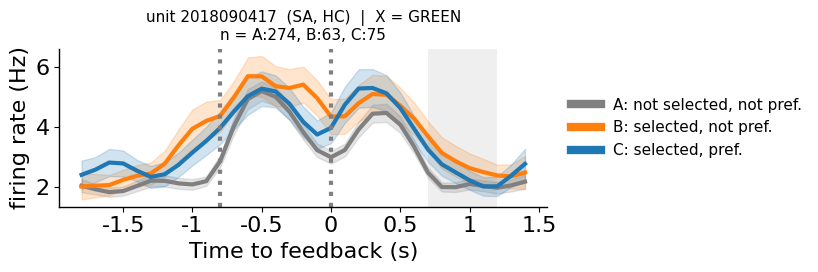

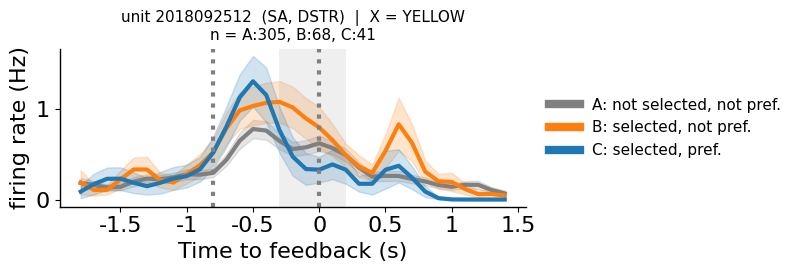

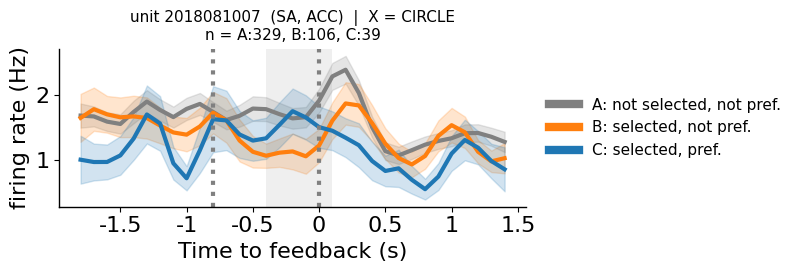

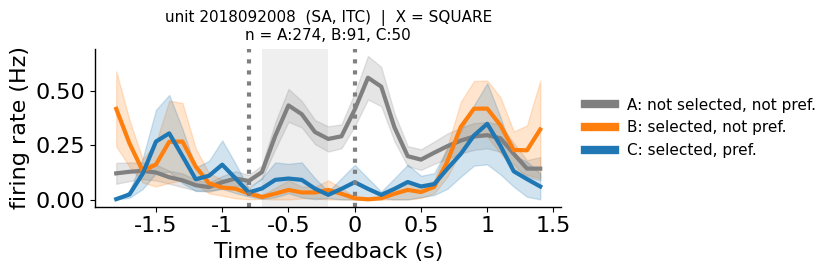

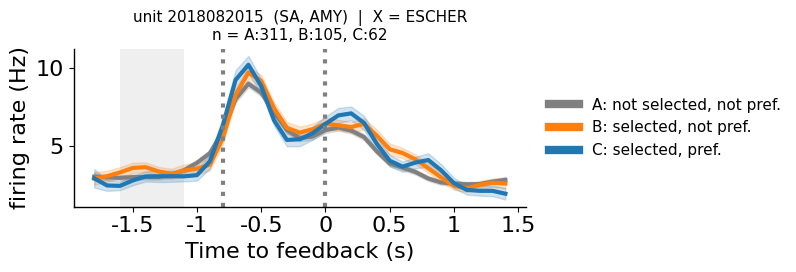

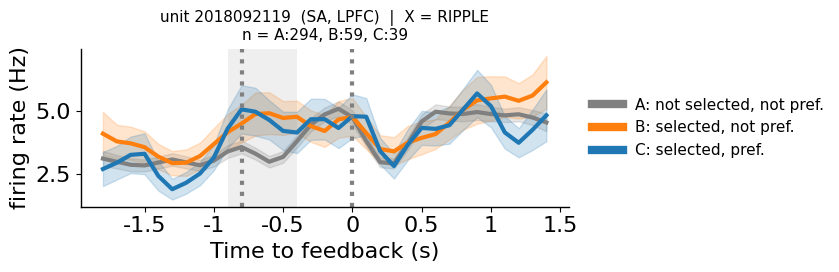

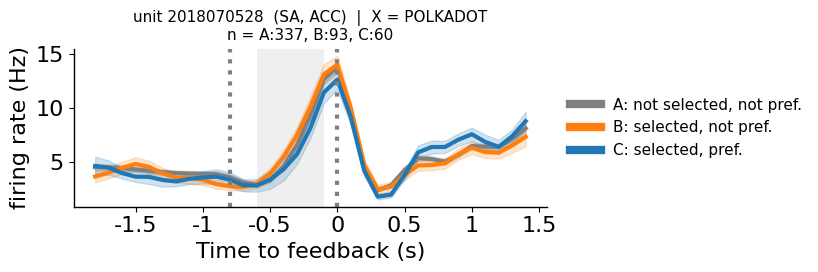

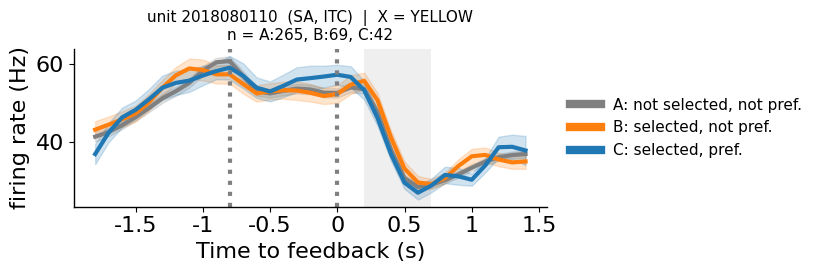

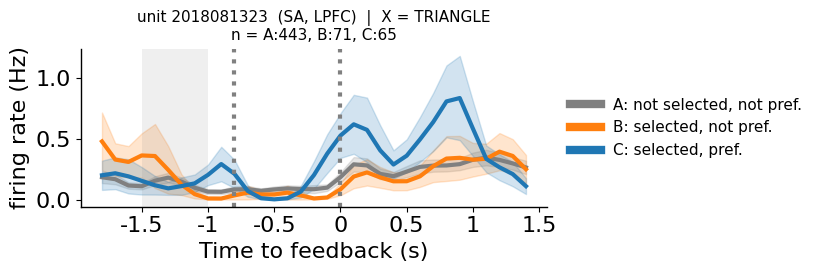

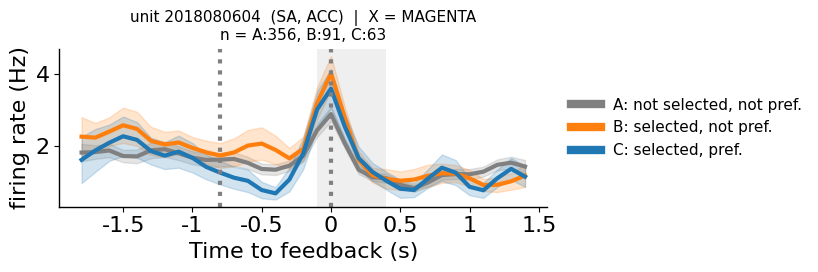

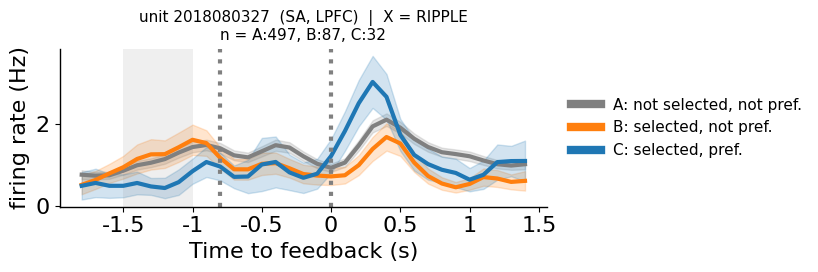

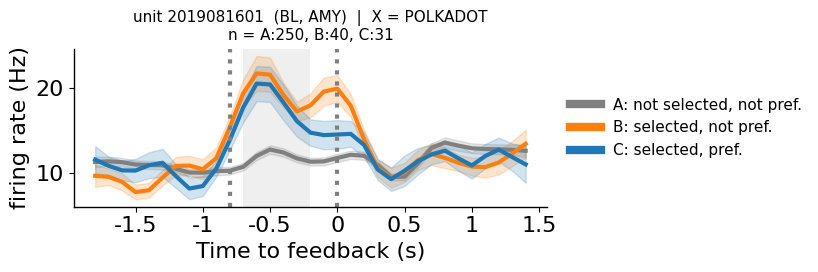

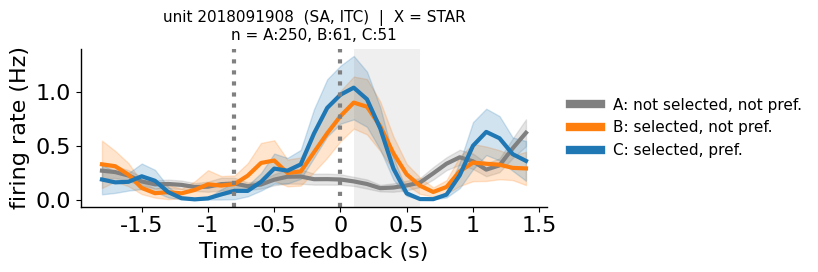

In [14]:
figs, axs = plot_examples(stim_examples)